## Ebola Outbreak Early Warning System EDA & Data Preparation

### ML-Powered Ebola Outbreak Prediction and Early Warning System for Rwanda

1. Exploratory Data Analysis 
2. Data Cleaning Pipeline
3. Output:

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 2. Load Data

In [2]:
df = pd.read_csv("ml_features_dataset.csv")

print(f"The size of the dataset is: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

The size of the dataset is: 210 rows x 7 columns


,Week,District,Active Regional Cases,Distance to Outbreak (km),Border Inflow Count,Transit Hub Count,Isolation Capacity Score
0,2026-W20,Rubavu,0.0,373.53,0.0,26,4
1,2026-W20,Rusizi,0.0,468.37,0.0,31,4
2,2026-W20,Nyagatare,0.0,318.72,0.0,21,3
3,2026-W20,Gicumbi,0.0,341.55,0.0,23,3
4,2026-W20,Nyarugenge,0.0,389.49,0.0,54,5


## 3. Variable Types & Structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Week                       210 non-null    str    
 1   District                   210 non-null    str    
 2   Active Regional Cases      210 non-null    float64
 3   Distance to Outbreak (km)  210 non-null    float64
 4   Border Inflow Count        210 non-null    float64
 5   Transit Hub Count          210 non-null    int64  
 6   Isolation Capacity Score   210 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 11.6 KB


## 4. Summary Statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Active Regional Cases,210.0,2.033333,4.770707,0.00,0.000,0.000,2.0000,32.00
Distance to Outbreak (km),210.0,134.165286,116.738476,9.61,63.530,97.310,142.8950,477.04
Border Inflow Count,210.0,5.605429,5.867494,0.00,1.195,4.985,6.6225,23.03
Transit Hub Count,210.0,24.900000,19.140740,7.00,16.000,21.000,27.0000,117.00
Isolation Capacity Score,210.0,3.333333,1.425447,2.00,3.000,3.000,4.0000,10.00


## 5. Check and handle missing values and duplicates

In [5]:
#checking for missing values
print("Missing Values in the dataset:")
print(df.isnull().sum())

Missing Values in the dataset:
Week                         0
District                     0
Active Regional Cases        0
Distance to Outbreak (km)    0
Border Inflow Count          0
Transit Hub Count            0
Isolation Capacity Score     0
dtype: int64


## Check and handle duplicates

In [6]:
#check for duplicates in the dataset
print("Duplicates:", df.duplicated().sum())


Duplicates: 0


## 6. Exploratory Visualizations

### 6.1 Distribution of Features

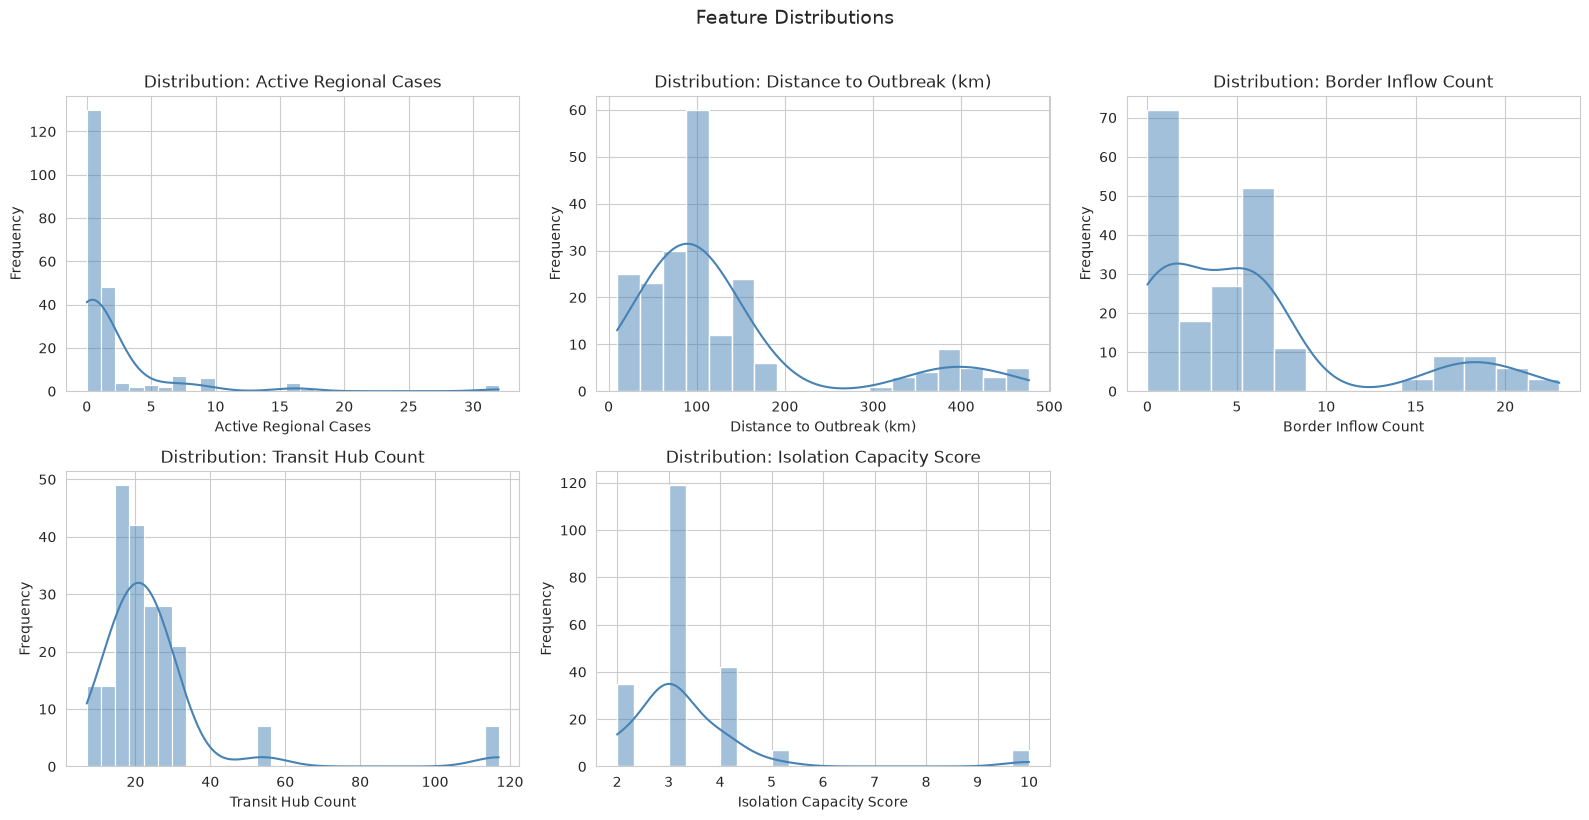

In [7]:
# Dataset distribution of features
numeric_cols = ["Active Regional Cases", "Distance to Outbreak (km)",
                "Border Inflow Count", "Transit Hub Count", "Isolation Capacity Score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
axes[-1].axis("off")
plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("distributions.png", bbox_inches="tight")
plt.show()

### 6.2 Outlier Detection (Boxplots)

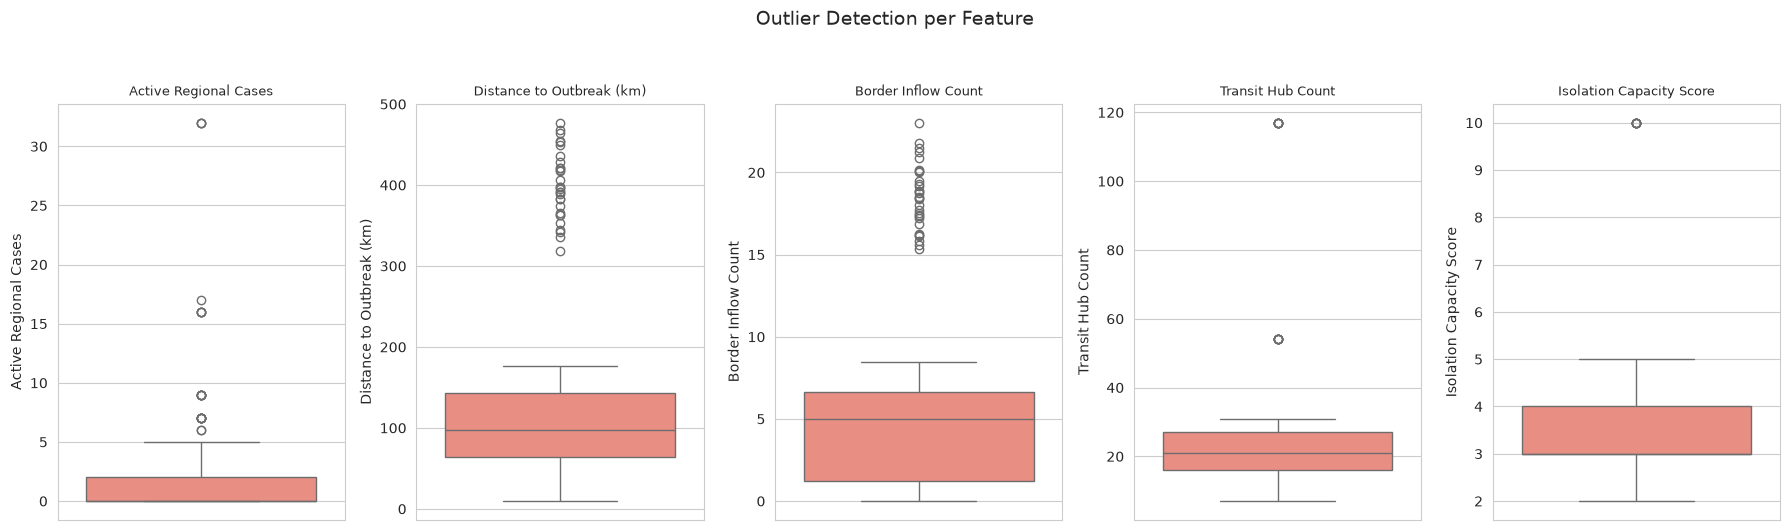

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="salmon")
    axes[i].set_title(col, fontsize=9)
plt.suptitle("Outlier Detection per Feature", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("outliers.png", bbox_inches="tight")
plt.show()

In [9]:
# IQR-based outlier count per feature 
def count_iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

pd.Series({c: count_iqr_outliers(df[c]) for c in numeric_cols}, name="outlier_count").to_frame()

,outlier_count
Active Regional Cases,23
Distance to Outbreak (km),30
Border Inflow Count,30
Transit Hub Count,14
Isolation Capacity Score,7


### 6.3 Correlation Heatmap

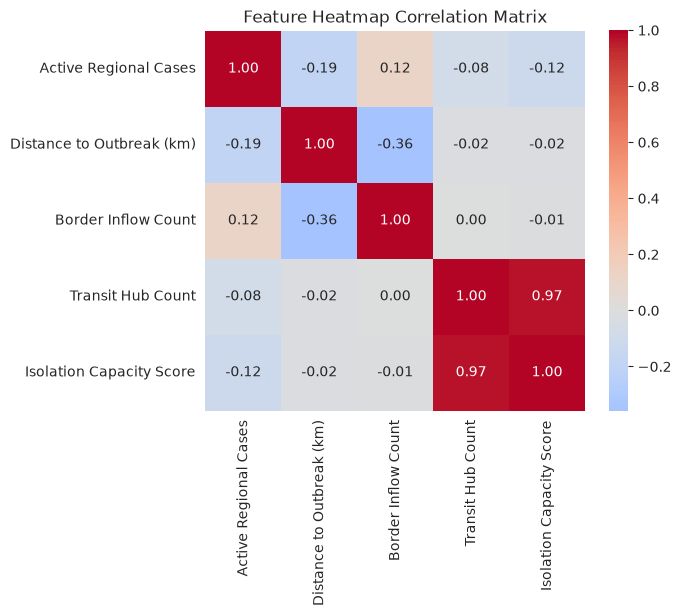

In [10]:
plt.figure(figsize=(7, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Heatmap Correlation Matrix")
plt.tight_layout()
plt.savefig("heatmap_correlation.png", bbox_inches="tight")
plt.show()

### 6.4 Active Cases Trend by Week

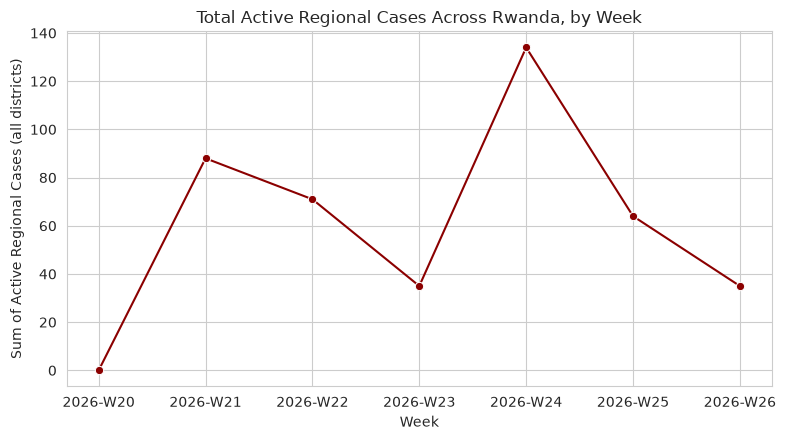

In [11]:
weekly_total = df.groupby("Week")["Active Regional Cases"].sum().reset_index()

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=weekly_total, x="Week", y="Active Regional Cases", marker="o", color="darkred")
plt.title("Total Active Regional Cases Across Rwanda, by Week")
plt.xlabel("Week")
plt.ylabel("Sum of Active Regional Cases (all districts)")
plt.tight_layout()
plt.savefig("weekly_trend.png", bbox_inches="tight")
plt.show()

### 7 Feature Engineering

In [12]:
df_clean = df.copy()
print(f"df_clean: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")

df_clean: 210 rows x 7 columns


In [13]:
df_clean = df_clean.sort_values(["District", "Week"]).reset_index(drop=True)

df_clean["Case_Trend"] = (
    df_clean.groupby("District")["Active Regional Cases"]
    .diff()
    .fillna(0)
)

df_clean[["Week", "District", "Active Regional Cases", "Case_Trend"]].head(10)

,Week,District,Active Regional Cases,Case_Trend
0,2026-W20,Bugesera,0.0,0.0
1,2026-W21,Bugesera,2.0,2.0
2,2026-W22,Bugesera,2.0,0.0
3,2026-W23,Bugesera,0.0,-2.0
4,2026-W24,Bugesera,0.0,0.0
5,2026-W25,Bugesera,0.0,0.0
6,2026-W26,Bugesera,0.0,0.0
7,2026-W20,Burera,0.0,0.0
8,2026-W21,Burera,9.0,9.0
9,2026-W22,Burera,5.0,-4.0


### 7.1  Weekly Case Context

In [14]:
national_weekly = df_clean.groupby("Week")["Active Regional Cases"].sum()
df_clean["National_Weekly_Cases"] = df_clean["Week"].map(national_weekly)

df_clean[["Week", "District", "Active Regional Cases", "National_Weekly_Cases"]].head(10)

,Week,District,Active Regional Cases,National_Weekly_Cases
0,2026-W20,Bugesera,0.0,0.0
1,2026-W21,Bugesera,2.0,88.0
2,2026-W22,Bugesera,2.0,71.0
3,2026-W23,Bugesera,0.0,35.0
4,2026-W24,Bugesera,0.0,134.0
5,2026-W25,Bugesera,0.0,64.0
6,2026-W26,Bugesera,0.0,35.0
7,2026-W20,Burera,0.0,0.0
8,2026-W21,Burera,9.0,88.0
9,2026-W22,Burera,5.0,71.0


### 7.2 Encoding Time
`Week` is stored as an ISO week string (e.g. `2026-W20`). Extract a numeric `Week_Number` for ordering/modeling while keeping the original string for labeling plots and results.

In [15]:
df_clean["Week_Number"] = df_clean["Week"].str.extract(r"W(\d+)").astype(int)

df_clean[["Week", "Week_Number"]].drop_duplicates().sort_values("Week_Number")

,Week,Week_Number
0,2026-W20,20
1,2026-W21,21
2,2026-W22,22
3,2026-W23,23
4,2026-W24,24
5,2026-W25,25
6,2026-W26,26


### 7.3 Scaling


In [16]:
feature_cols = ["Active Regional Cases", "Distance to Outbreak (km)", "Border Inflow Count",
                "Isolation Capacity Score", "Case_Trend", "National_Weekly_Cases", "Week_Number"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[feature_cols]),
    columns=[f"{c}_scaled" for c in feature_cols],
)

df_model_ready = pd.concat(
    [df_clean[["Week", "District"]].reset_index(drop=True), X_scaled], axis=1
)
df_model_ready.head()

,Week,District,Active Regional Cases_scaled,Distance to Outbreak (km)_scaled,Border Inflow Count_scaled,Isolation Capacity Score_scaled,Case_Trend_scaled,National_Weekly_Cases_scaled,Week_Number_scaled
0,2026-W20,Bugesera,-0.427231,2.445168,-0.957619,-0.937614,-0.039133,-1.522284,-1.5
1,2026-W21,Bugesera,-0.007004,-0.082305,-0.662070,-0.937614,0.430463,0.673798,-1.0
2,2026-W22,Bugesera,-0.007004,-0.087801,-0.781656,-0.937614,-0.039133,0.249555,-0.5
3,2026-W23,Bugesera,-0.427231,-0.082305,-0.151265,-0.937614,-0.508729,-0.648842,0.0
4,2026-W24,Bugesera,-0.427231,-0.082305,-0.004344,-0.937614,-0.039133,1.821750,0.5


### 7.4 Save Scaler for Deployment
The backend will need to scale new incoming data the same way the training data was scaled, so the fitted `StandardScaler` is persisted alongside the dataset, not refit on new data.

In [17]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
print("Saved: scaler.pkl, feature_cols.pkl")

Saved: scaler.pkl, feature_cols.pkl


### 7.5 Anomaly Detection Preparation

In [18]:
X = df_model_ready.drop(columns=["Week", "District"])
ids = df_model_ready[["Week", "District"]]

print(f"Model-ready feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
X.describe().T

Model-ready feature matrix: 210 rows x 7 columns


,count,mean,std,min,25%,50%,75%,max
Active Regional Cases_scaled,210.0,-1.268826e-17,1.002389,-0.427231,-0.427231,-0.427231,-0.007004,6.296398
Distance to Outbreak (km)_scaled,210.0,-2.537653e-17,1.002389,-1.069510,-0.606519,-0.316463,0.074959,2.944137
Border Inflow Count_scaled,210.0,-7.718693e-17,1.002389,-0.957619,-0.753468,-0.105993,0.173754,2.976775
Isolation Capacity Score_scaled,210.0,-9.727668e-17,1.002389,-0.937614,-0.234404,-0.234404,0.468807,4.688072
Case_Trend_scaled,210.0,5.075305e-17,1.002389,-3.795903,-0.039133,-0.039133,-0.039133,5.830821
National_Weekly_Cases_scaled,210.0,7.401487e-18,1.002389,-1.522284,-0.648842,0.074866,0.673798,1.821750
Week_Number_scaled,210.0,0.000000e+00,1.002389,-1.500000,-1.000000,0.000000,1.000000,1.500000


In [19]:
df_model_ready.to_csv("model_ready_dataset.csv", index=False)
print("Dataset ready for input for Isolation Forest training")

Dataset ready for input for Isolation Forest training
